# Object Detection and Image Segmentation

<div class='alert alert-warning'>

:::{Attention}
The audiences are welcome to have a deep dive using the book [here](https://d2l.ai/index.html), which is also the material the current notebook refers to. Of course we encourage the participants to check the cited paper as well if they want to gain a more thorough understanding.
:::
</div>

## 1. Introduction to object detection and image segmentation

### 1.1 Difference between classification, localization and detection

<img src="https://cdn.labellerr.com/why%20do%20autonomous%20vehicles%20Need%20object%20detection%3F/3.webp" width="500"/>

**Image classification:** Predict the class of an object

**Object localization:** Locate the presence of objects and indicate their location with bounding boxes

**Object detection:** Locate the presence of objects with bounding boxes and classes of the located objects

### 1.2 Image segmentation

#### **Object detection vs. Instance segmentation**

<img src="https://miro.medium.com/v2/resize:fit:640/format:webp/0*VX1UNfrNgjRD24Kq.jpg" width="400"/>

Image segmentation is a further extension of object detection in the sense that the presence of the object is marked through pixel-wise masks. This can help us in determining the shape of each object present in the image. Such granularity is needed in various fields such as material defect characterization, medical image processing, satellite image, and etc.

In the example shown above, we have two dogs in the image and they would be represented as two different label classes in *Instance segmention*

#### **Instance segmentation vs. Semantic segmentaion**

While in semantic segmentation, two dogs or two cats in an image will be labelled as one class as "dog" or "cat", instead of "dog1, dog2", or "cat1, cat2" as in instance segmentation.

<img src="https://datahacker.rs/wp-content/uploads/2021/11/image-19-1024x313.png" width="600"/>

### 1.3 Objection detection as a combination of classification and regression problems

The definition of object detection naturally consists of two parts: 

(1) Detecting the class of the object (classification)

Note that in object detection, we want to detect all the objects whether they belong to the same class or not.

(2) Detecting the position of the object using bounding boxes (Regression)

In object detection, the regression network needs to predict four floating-point number per detected object, representing the bounding box coordinates (upper-left x and y, lower-right x and y) for each object. 

More specifically speaking:

Object classification outputs a probability for each class, for example, $\left[c_1, c_2\right]$ where $c_1$ and $c_2$ are the probabilities of class 1 and class 2.

Object detection extends this with localization: the model must also predict where the object is. Each detection therefore outputs $\left[P, C_x, C_y, w, h, c_1, c_2\right]$, where $P$ is the confidence that an object is present, $\left(C_x, C_y\right)$ is the bounding box centre, $w$ and $h$ are its width and height, and $c_1, c_2$ are the class probabilities.

<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*2HzDlBGgL8iTyfEaWDb5QQ.png" width="600"/>

Before we dive into the methods used for object detection and segmentation, let's first learn about some foundamental concepts!

## 2. Object Detection Fundamentals

### 2.1 Bounding box

In object detection, a **bounding box** is usually used to describe the spatial location of an object. The bounding box is in rectangular shape, which can be determined by the x, y coordinates of the upper-left corner and lower-right corner. Another commonly used representation is the (x, y)-axis coordinates of the bounding box center, and the width and height of the box. Nevertheless, it is easy to define functions that convert between these two representations. 

In [3]:
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
from PIL import Image
from io import BytesIO

# ── Bounding box conversion functions ──────────────────────────────────────────

def box_corner_to_center(boxes):
    """Convert from (upper-left, lower-right) to (center, width, height)."""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    return torch.stack((cx, cy, w, h), dim=-1)

def box_center_to_corner(boxes):
    """Convert from (center, width, height) to (upper-left, lower-right)."""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack((x1, y1, x2, y2), dim=-1)

# The input argument boxes should be a two-dimensional tensor of shape (n, 4), where n is the number of bounding boxes.

Let's try to add bounding boxes to our dog-cat image.

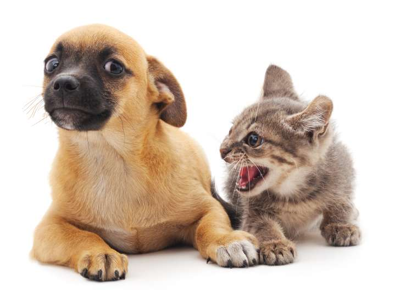

In [5]:
import requests
from PIL import Image
from io import BytesIO
from IPython.display import display
url = "https://raw.githubusercontent.com/d2l-ai/d2l-en/master/img/catdog.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
display(img.resize((400, int(img.height * 400 / img.width))))

In [60]:
# Define a helper function
def bbox_to_rect(bbox, color):
    """Convert bounding box to a matplotlib Rectangle patch."""
    # bbox: (upper-left x, upper-left y, lower-right x, lower-right y)
    return patches.Rectangle(
        xy=(bbox[0], bbox[1]),
        width=bbox[2] - bbox[0],
        height=bbox[3] - bbox[1],
        fill=False, edgecolor=color, linewidth=2
    )

In [61]:
# ── Verify round-trip conversion ───────────────────────────────────────────────

dog_bbox = [60.0, 45.0, 378.0, 516.0]
cat_bbox = [400.0, 112.0, 655.0, 493.0]

boxes = torch.tensor((dog_bbox, cat_bbox))
print(box_center_to_corner(box_corner_to_center(boxes)) == boxes)

tensor([[True, True, True, True],
        [True, True, True, True]])


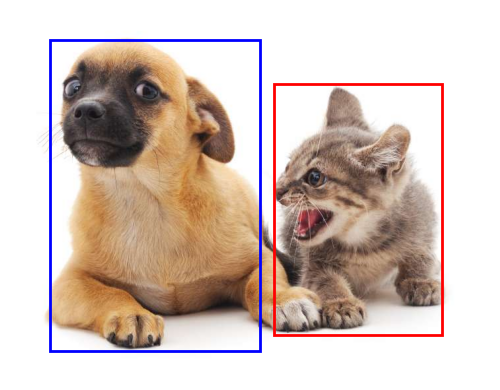

In [62]:
# ── Plot image with bounding boxes ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.imshow(img)
ax.add_patch(bbox_to_rect(dog_bbox, 'blue'))
ax.add_patch(bbox_to_rect(cat_bbox, 'red'))
ax.axis('off')
plt.tight_layout()
plt.show()

### 2.2 Anchor Boxes
#### 2.2.1 Anchor generation

Suppose that the input image has a height of $H$ and width of $W$. Given $n$ scales and $m$ aspect ratios, anchor boxes are generated centered on each pixel of the image. Rather than using all $n \times m$ combinations, each pixel gets $n + m - 1$ anchors (one per scale paired with $r_1$, plus $s_1$ paired with each remaining ratio). All coordinates are normalised to $[0, 1]$.

**Why only combinations with $s_1$ or $r_1$?**
With $n$ scales and $m$ ratios, using every $(s_i, r_j)$ pair would produce $n \times m$ anchors per pixel — for the 3×3 case 9 instead of 5 — multiplying memory and NMS cost across all pixels. The reduction is justified because extreme cross-combinations like $(s_3, r_3)$ (a large-scale, wide-ratio box) are rarely matched to real objects and add little coverage that the other anchors don't already provide.

**The rule of thumb is:** vary aspect ratio at the smallest scale $(s_1, r_k)$ because small objects appear in the most diverse shapes, and vary scale at the default ratio $(s_k, r_1)$ because larger objects tend to have near-square bounding boxes. This $n + m - 1$ heuristic originates from the [SSD paper](https://arxiv.org/abs/1512.02325); later approaches like YOLOv2+ replaced it by running $k$-means clustering on all ground-truth box dimensions in the training set. The idea is simple: collect every annotated box in your dataset, plot them by width and height, and let the algorithm automatically find $k$ "typical shapes" that best represent the spread. Those $k$ representative shapes become the anchors, so instead of guessing a hand-crafted grid of scales and ratios, you get priors that directly reflect what objects in your specific dataset actually look like.

In [63]:
def multibox_prior(data, sizes, ratios):
    """Generate anchor boxes with different shapes centered on each pixel."""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1)
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)
    # Offsets are required to move the anchor to the center of a pixel. Since
    # a pixel has height=1 and width=1, we choose to offset our centers by 0.5
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height  # Scaled steps in y axis
    steps_w = 1.0 / in_width  # Scaled steps in x axis

    # Generate all center points for the anchor boxes
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    # Generate `boxes_per_pixel` number of heights and widths that are later
    # used to create anchor box corner coordinates (xmin, xmax, ymin, ymax)
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),
                   sizes[0] * torch.sqrt(ratio_tensor[1:])))\
                   * in_height / in_width  # Handle rectangular inputs
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),
                   sizes[0] / torch.sqrt(ratio_tensor[1:])))
    # Divide by 2 to get half height and half width
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
                                        in_height * in_width, 1) / 2

    # Each center point will have `boxes_per_pixel` number of anchor boxes, so
    # generate a grid of all anchor box centers with `boxes_per_pixel` repeats
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1).repeat_interleave(boxes_per_pixel, dim=0)
    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)

In [64]:
import numpy as np

img_t = torch.tensor(np.array(img)).permute(2, 0, 1).unsqueeze(0).float()
h, w  = img_t.shape[-2:]
print(f'Image size: {h}×{w}')

anchors = multibox_prior(img_t, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
print(f'Anchor tensor shape: {anchors.shape}')
print(f'Expected (1, {h}×{w}×5, 4) = (1, {h*w*5}, 4)')

Image size: 561×728
Anchor tensor shape: torch.Size([1, 2042040, 4])
Expected (1, 561×728×5, 4) = (1, 2042040, 4)


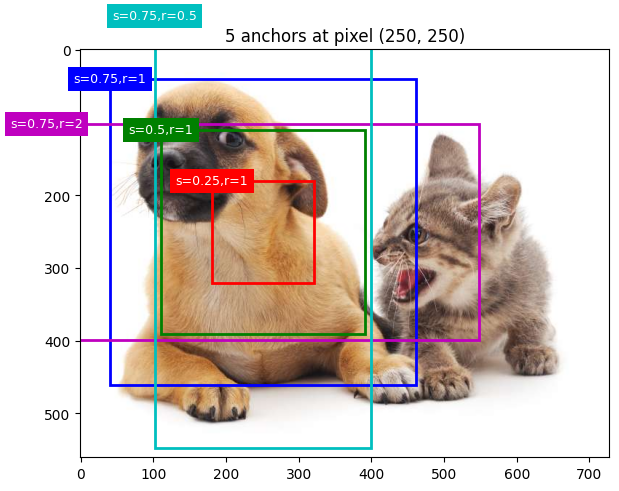

In [66]:
# Visualise the 5 anchor shapes at a single pixel

def show_bboxes(axes, bboxes, labels=None, colors=None):
    """Show bounding boxes."""

    def make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = make_list(labels)
    colors = make_list(colors, ['b', 'g', 'r', 'm', 'c'])
    for i, bbox in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = bbox_to_rect(bbox.detach().numpy(), color)
        axes.add_patch(rect)
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w'
            axes.text(rect.xy[0], rect.xy[1], labels[i],
                      va='center', ha='center', fontsize=9, color=text_color,
                      bbox=dict(facecolor=color, lw=0))

boxes_per_pixel = 5
pixel_row, pixel_col = 250, 250
pixel_idx     = pixel_row * w + pixel_col
pixel_anchors = anchors[0, pixel_idx*boxes_per_pixel : (pixel_idx+1)*boxes_per_pixel]

# Convert [0,1] → pixel coordinates
pixel_anchors_px = pixel_anchors * torch.tensor([w, h, w, h], dtype=torch.float)

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(img)
show_bboxes(ax, pixel_anchors_px,
            labels=['s=0.75,r=1','s=0.5,r=1','s=0.25,r=1','s=0.75,r=2','s=0.75,r=0.5'])
ax.set_title(f'5 anchors at pixel ({pixel_col}, {pixel_row})')
plt.tight_layout()
plt.show()

The blue anchor box with a scale of 0.75 and an aspect ratio of 1 well surrounds the dog in the image.

But the question is: how can "well" here be quantified?

**The answer is: by measuring similarities**

#### 2.2.2 Intersection over Union (IoU) as an evaluation metric

IoU is a key metric for measuring the overlap between a predicted bounding box and the groundtruth bounding box.
Also known as Jaccard index, IoU is defined as the ratio of the intersection area to the union area between the two bounding boxes ($J(\mathcal{A}, \mathcal{B})=\frac{|\mathcal{A} \cap \mathcal{B}|}{|\mathcal{A} \cup \mathcal{B}|}$).

We will use IoU to measure the similarity between anchor boxes and ground-truth bounding boxes.
A higher IoU value indicates better alignment between the predicted and groundtruth bounding boxes.

<img src="https://d2l.ai/_images/iou.svg" width="400"/>



In [67]:
def box_iou(boxes1, boxes2):
    """Compute pairwise IoU across two lists of anchor or bounding boxes."""
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) *
                              (boxes[:, 3] - boxes[:, 1]))
    # Shape of `boxes1`, `boxes2`, `areas1`, `areas2`: (no. of boxes1, 4),
    # (no. of boxes2, 4), (no. of boxes1,), (no. of boxes2,)
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)
    # Shape of `inter_upperlefts`, `inter_lowerrights`, `inters`: (no. of
    # boxes1, no. of boxes2, 2)
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)
    # Shape of `inter_areas` and `union_areas`: (no. of boxes1, no. of boxes2)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    union_areas = areas1[:, None] + areas2 - inter_areas
    return inter_areas / union_areas

> --- Preparing training labels (offline, uses ground truth) ---

#### 2.2.3 Assigning ground-truth boxes to anchors

Before training, every anchor box must be told what it is responsible for predicting. This is decided once, offline, using the ground-truth boxes already provided in the dataset.

Given an image, suppose the anchor boxes are $A_1, A_2, \ldots, A_{n_a}$ and the ground-truth boxes are $B_1, B_2, \ldots, B_{n_b}$, where $n_a \geq n_b$ (there are always more anchors than objects). Define the matrix $\mathbf{X} \in \mathbb{R}^{n_a \times n_b}$, where each element $x_{ij}$ is the IoU between anchor $A_i$ and ground-truth box $B_j$.

**Assignment algorithm:**

1. Find the largest element in $\mathbf{X}$ across all remaining rows and columns — this identifies the anchor-ground-truth pair with highest overlap.
2. Assign that pair: the anchor takes on the corresponding ground-truth box.
3. Discard that anchor's row and that ground-truth box's column from further consideration — each anchor and each ground-truth box can only be matched once at this stage.
4. Repeat steps 1–3 until every ground-truth box has been assigned to an anchor.

This guarantees each ground-truth box gets matched to its single best-overlapping anchor, and no anchor is "wasted" on a box that's already been claimed by a better match.

**Leftover anchors**

Since $n_a \geq n_b$, most anchors will not be assigned by this process. For each leftover anchor, compute its IoU with every ground-truth box and take the maximum:

- If this maximum IoU exceeds a chosen threshold (e.g. 0.5), the anchor is assigned to that ground-truth box's class.
- Otherwise, the anchor is labelled **background** — it isn't responsible for predicting any object.

This second pass ensures anchors with a strong but non-maximal overlap still contribute useful training signal, rather than being discarded just because another anchor matched the same box even more closely.

<img src="https://d2l.ai/_images/anchor-label.svg" width="600"/>

Process: finding global max --> discarding the row and column it is located --> repeat this process until we have assigned $n_b$ ground-truth bounding boxes.

As demonstrated in the figure above, $B_3$ is assigned to $A_2$, $B_1$ is assigned to $A_7$, $B_4$ is assigned to $A_5$, and $B_2$ is assigned to $A_9$. Then, according to the threshold, it will be determined for the remaining anchor boxes $A_1, A_3, A_4, A_6, A_8$ if they will be assigned a ground-truth bounding box or not.

In [68]:
def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """Assign closest ground-truth bounding boxes to anchor boxes."""
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    # Element x_ij in the i-th row and j-th column is the IoU of the anchor
    # box i and the ground-truth bounding box j
    jaccard = box_iou(anchors, ground_truth)
    # Initialize the tensor to hold the assigned ground-truth bounding box for
    # each anchor
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long,
                                  device=device)
    # Assign ground-truth bounding boxes according to the threshold
    max_ious, indices = torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)
    box_j = indices[max_ious >= iou_threshold]
    anchors_bbox_map[anc_i] = box_j
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        max_idx = torch.argmax(jaccard)  # Find the largest IoU
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx / num_gt_boxes).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
    return anchors_bbox_map

#### 2.2.4 Labels for each anchor

Once every anchor has been assigned (either to a ground-truth box, or to background), two labels are derived for it:

**Class label**

For an anchor box $A$ that is matched to ground-truth box $B$, the class of $A$ is labelled as the class of $B$. Anchors matched to no ground-truth box (background) receive a special background class.

**Offset label**

Regarding the offset, we apply transformations to the relative positions and sizes of boxes $A$ and $B$, given the varying positions and sizes of different boxes in the dataset, in order to work with more uniformly distributed offsets that are easier to fit.

A common transformation, given the central coordinates of $A$ and $B$ as $(x_a, y_a)$ and $(x_b, y_b)$, their widths as $w_a$ and $w_b$, and their heights as $h_a$ and $h_b$, respectively, the offset of $A$ is labelled as:

$$
\left(\frac{\frac{x_b-x_a}{w_a}-\mu_x}{\sigma_x}, \frac{\frac{y_b-y_a}{h_a}-\mu_y}{\sigma_y}, \frac{\log \frac{w_b}{w_a}-\mu_w}{\sigma_w}, \frac{\log \frac{h_b}{h_a}-\mu_h}{\sigma_h}\right)
$$

Default values of the constants are $\mu_x=\mu_y=\mu_w=\mu_h=0$, $\sigma_x=\sigma_y=0.1$, and $\sigma_w=\sigma_h=0.2$.

Background anchors have no meaningful offset, since there is no ground-truth box to regress toward.

In [69]:
def offset_boxes(anchors, assigned_bb, eps=1e-6):
    """Transform for anchor box offsets."""
    c_anc = box_corner_to_center(anchors)
    c_assigned_bb = box_corner_to_center(assigned_bb)
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    return offset

**Brief summary**

Given a set of ground-truth (GT) boxes, each anchor is assigned a label:

| Condition | Label |
|---|---|
| Best anchor for a GT box (by IoU) | **Positive** — that GT class |
| IoU ≥ threshold with any GT box | **Positive** |
| IoU < threshold (and not best) | **Background (0)** |

In the function below, the background class is set to zero and a new class is assigned with an integer index of increments by one.

In [70]:
def multibox_target(anchors, labels):
    """Label anchor boxes using ground-truth bounding boxes."""
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox(
            label[:, 1:], anchors, device)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(
            1, 4)
        # Initialize class labels and assigned bounding box coordinates with
        # zeros
        class_labels = torch.zeros(num_anchors, dtype=torch.long,
                                   device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32,
                                  device=device)
        # Label classes of anchor boxes using their assigned ground-truth
        # bounding boxes. If an anchor box is not assigned any, we label its
        # class as background (the value remains zero)
        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true]
        class_labels[indices_true] = label[bb_idx, 0].long() + 1
        assigned_bb[indices_true] = label[bb_idx, 1:]
        # Offset transformation
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    bbox_offset = torch.stack(batch_offset)
    bbox_mask = torch.stack(batch_mask)
    class_labels = torch.stack(batch_class_labels)
    return (bbox_offset, bbox_mask, class_labels)

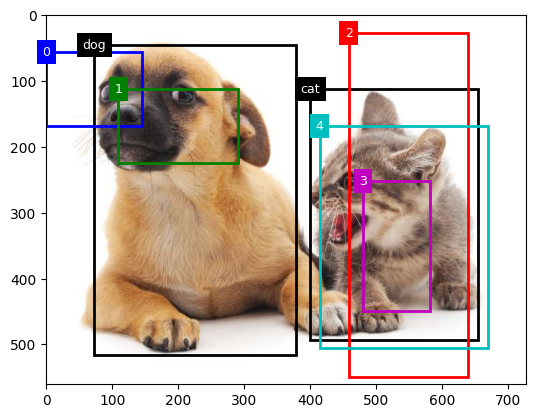

In [71]:
bbox_scale = torch.tensor((w, h, w, h))
ground_truth = torch.tensor([[0, 0.1, 0.08, 0.52, 0.92],
                         [1, 0.55, 0.2, 0.9, 0.88]])
anchors = torch.tensor([[0, 0.1, 0.2, 0.3], [0.15, 0.2, 0.4, 0.4],
                    [0.63, 0.05, 0.88, 0.98], [0.66, 0.45, 0.8, 0.8],
                    [0.57, 0.3, 0.92, 0.9]])

fig = plt.imshow(img)
show_bboxes(fig.axes, ground_truth[:, 1:] * bbox_scale, ['dog', 'cat'], 'k')
show_bboxes(fig.axes, anchors * bbox_scale, ['0', '1', '2', '3', '4']);

In [37]:
# Ground truth: (class, x1, y1, x2, y2) in [0,1] coords
labels = torch.tensor([[
    [0.,  0.1,  0.08, 0.52, 0.92],   # dog  (class 0)
    [1.,  0.55, 0.2,  0.9,  0.88],   # cat  (class 1)
]])

anchors_small = multibox_prior(img_t, sizes=[0.15, 0.3, 0.6], ratios=[1, 2])
offsets, masks, cls_tgts = multibox_target(anchors_small, labels)

print(f'Anchor tensor shape  : {anchors_small.shape}')
print(f'Offset targets shape : {offsets.shape}')
print(f'Mask shape           : {masks.shape}')
print(f'Class targets shape  : {cls_tgts.shape}')
print(f'Positive anchors     : {(cls_tgts > 0).sum().item()}')
print(f'Background anchors   : {(cls_tgts == 0).sum().item()}')

Anchor tensor shape  : torch.Size([1, 1633632, 4])
Offset targets shape : torch.Size([1, 6534528])
Mask shape           : torch.Size([1, 6534528])
Class targets shape  : torch.Size([1, 1633632])
Positive anchors     : 51358
Background anchors   : 1582274


> --- Using the trained model (inference, no ground truth) ---

#### 2.2.5 Bounding box prediction with non-maximum suppression (NMS)

During prediction, multiple anchor boxes would be generated for the image, and the classes and offsets for each of the boxes are predicted. In other words, a predicted bounding box is obtained according to an anchor box with its predicted offset.

In [73]:
def offset_inverse(anchors, offset_preds):
    """Predict bounding boxes based on anchor boxes with predicted offsets."""
    anc = box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    predicted_bbox = box_center_to_corner(pred_bbox)
    return predicted_bbox

The similar predicted bounding boxes that belong to the same object are merged by using non-maximum suppression (NMS).

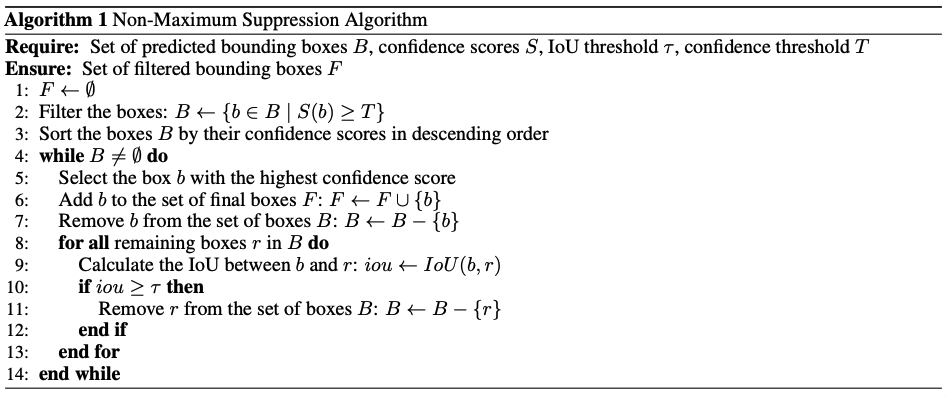

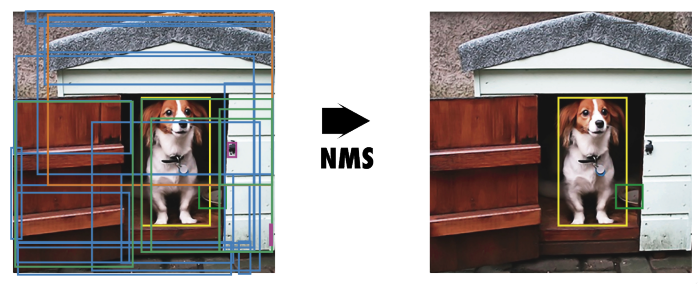

In [6]:
from IPython.display import HTML, display, Image
display(Image('./Fig/04_NMS_algo.png', width=800))
display(Image('./Fig/04_NMS_image.png', width=800))

Please refer to this [paper](https://arxiv.org/pdf/2304.00501) for more details

In [74]:
def nms(boxes, scores, iou_threshold):
    """Sort confidence scores of predicted bounding boxes."""
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []  # Indices of predicted bounding boxes that will be kept
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1: break
        iou = box_iou(boxes[i, :].reshape(-1, 4),
                      boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, device=boxes.device)

In [76]:
def multibox_detection(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                       pos_threshold=0.009999999):
    """Predict bounding boxes using non-maximum suppression."""
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0)
        predicted_bb = offset_inverse(anchors, offset_pred)
        keep = nms(predicted_bb, conf, nms_threshold)
        # Find all non-`keep` indices and set the class to background
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1
        class_id = class_id[all_id_sorted]
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        # Here `pos_threshold` is a threshold for positive (non-background)
        # predictions
        below_min_idx = (conf < pos_threshold)
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx]
        pred_info = torch.cat((class_id.unsqueeze(1),
                               conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
    return torch.stack(out)

To illustrate how the algorithm works in practice, we walk through a concrete example using four anchor boxes. For simplicity, we assume all predicted offsets are zero, meaning the predicted bounding boxes coincide exactly with the anchor boxes. We also define a predicted probability for each class — background, dog, and cat.

In [77]:
anchors = torch.tensor([[0.1, 0.08, 0.52, 0.92], [0.08, 0.2, 0.56, 0.95],
                      [0.15, 0.3, 0.62, 0.91], [0.55, 0.2, 0.9, 0.88]])
offset_preds = torch.tensor([0] * anchors.numel())
cls_probs = torch.tensor([[0] * 4,  # Predicted background likelihood
                      [0.9, 0.8, 0.7, 0.1],  # Predicted dog likelihood
                      [0.1, 0.2, 0.3, 0.9]])  # Predicted cat likelihood

The predicted bounding boxes with their confidence can then be plotted on the image.

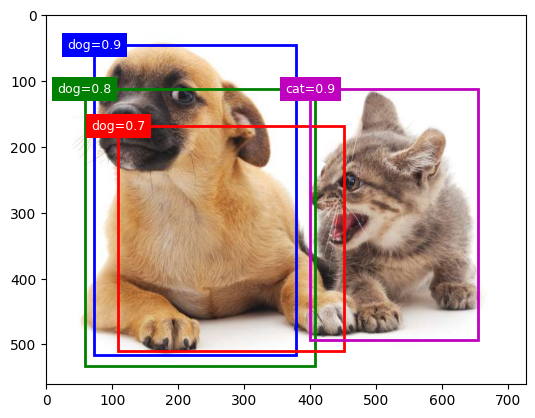

In [78]:
fig = plt.imshow(img)
show_bboxes(fig.axes, anchors * bbox_scale,
            ['dog=0.9', 'dog=0.8', 'dog=0.7', 'cat=0.9'])

We then invoke the *multibox_detection* function to perform NMS, where the threshold is set to 0.5.

In [79]:
output = multibox_detection(cls_probs.unsqueeze(dim=0),
                            offset_preds.unsqueeze(dim=0),
                            anchors.unsqueeze(dim=0),
                            nms_threshold=0.5)
output

tensor([[[ 0.0000,  0.9000,  0.1000,  0.0800,  0.5200,  0.9200],
         [ 1.0000,  0.9000,  0.5500,  0.2000,  0.9000,  0.8800],
         [-1.0000,  0.8000,  0.0800,  0.2000,  0.5600,  0.9500],
         [-1.0000,  0.7000,  0.1500,  0.3000,  0.6200,  0.9100]]])

In [80]:
output.shape

torch.Size([1, 4, 6])

The shape of the returned result is (batch size, number of anchor boxes, 6).
The six elements in the innermost dimension gives the output information for the same predicted bounding box. 

The first element is the predicted class index: 0 is dog and 1 is cat; the value -1 indicates background or removal in non-maximum suppression. 

The second element is the confidence of the predicted bounding box. 

The remaining four elements are the $(x, y)$-axis coordinates of the upper-left corner and the lower-right corner of the predicted bounding box, respectively (range is between 0 and 1).

**After removing class with -1:**

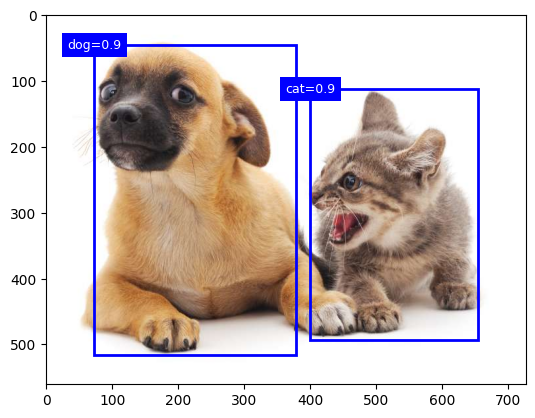

In [81]:
fig = plt.imshow(img)
for i in output[0].detach().numpy():
    if i[0] == -1:
        continue
    label = ('dog=', 'cat=')[int(i[0])] + str(i[1])
    show_bboxes(fig.axes, [torch.tensor(i[2:]) * bbox_scale], label)

## 3. From CNN to Yolo (You Only Look it Once)

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>🔗 Connection to Episodes 2 and 3</strong>
<p>The CNN classifier used in each crop here is exactly the architecture studied in <a href="../2-CNN-LeNet-AlexNet-lesson/">Episode 2 (CNN Fundamentals — LeNet, AlexNet)</a> and <a href="../3-TL-VGG-ResNet-ViT-lesson/">Episode 3 (Transfer Learning — VGG, ResNet, ViT)</a>. The backbone–head separation introduced in Episode 3 directly maps onto the feature extractor–detection head separation that Faster R-CNN and YOLO formalise: the backbone extracts features once from the full image, and the detection head replaces the classification head to predict boxes and classes instead of a single image-level label.</p>
</div>

### 3.1 CNN

Going back to the classfication + localization problem, the most straightforward idea: slide a fixed-size window across the image at
multiple scales and positions, run a CNN classifier on each crop, and keep the windows where the classifier fires with high confidence.

```
for each scale:
    for each (x, y) position:
        crop = image[y:y+h, x:x+w]
        label, score = CNN(crop)
```

**Problem:** the number of crops is enormous. For a 600×800 image with windows at 3 scales and a stride of 8 pixels, you get tens of thousands of crops - each requiring a full CNN forward pass. 

| Method | Speed | Notes |
|---|---|---|
| Sliding window + CNN | ~minutes/image | Too slow for any practical use |

### 3.2 Region-based CNN (R-CNN)

**Key insight:** instead of exhaustively scanning all windows, first propose a small set of *candidate regions* that are likely to contain objects, then
classify only those.

**How it works**
1. **Region proposals** : use *Selective Search*, a classical CV algorithm that groups pixels by colour and texture similarity, to generate ~2,000 candidate
   bounding boxes per image.
2. **Warp** each proposal to a fixed size (e.g. 227×227).
3. **Extract features** : run a CNN on each warped crop to get a feature vector.
4. **Classify** : feed each feature vector into a class-specific SVM (support vector machine).
5. **Refine** : run a bounding box regression to tighten the box.

**Remaining problem**
- Each of the ~2,000 proposals is processed **independently**. The CNN runs 2,000 separate forward passes per image! In this regard, the R-CNN is still far too slow for real-time use.

Later [R-CNN minus R](https://arxiv.org/abs/1506.06981) replaces Selective Search with static bounding box proposals, which is much faster than R-CNN. However, it still falls short of real-time and suffer from not having good proposals which would lead to significant accuracy decrease.

### 3.3 Fast R-CNN

**Key insight:** run the CNN *once* on the whole image to produce a shared feature map, then extract features for each region proposal from that map,
instead of running the CNN 2000 times.

**How it works*8
1. Run a CNN on the full image → shared **feature map** (computed once).
2. Project each region proposal onto the feature map.
3. Use **RoI (Region of Interest) Pooling** to extract a fixed-size feature vector for each proposal from the shared feature map.
4. Feed each feature vector into a classification head and a box regression head.

The CNN runs only **once** regardless of the number of proposals, which is a massive speedup. However, now the proposal step becomes the new bottleneck.

```
Input image
    │
    ├─ CNN (once) ──────────────────► shared feature map
    │                                        │
    └─ Selective Search → proposals → RoI Pooling → classification + box regression
                          (CPU, slow!)
```

See [reference](https://arxiv.org/abs/1504.08083) here.

### 3.4 Faster R-CNN

**Key insight:** It replace Selective Search with a small neural network, **Region Proposal Network (RPN)**, which shares the same feature map as
the detection head.

**How it work**
1. Run a backbone CNN on the full image → shared feature map.
2. **RPN** slides over the feature map and, at each position, proposes anchor boxes and scores them as object / not-object. This is fast because it shares the feature map.
3. The top-scoring proposals are passed to the detection head via RoI Pooling (same as Fast R-CNN).

However, it is still a **two-stage** pipeline: first propose, then classify. Each stage adds latency. For real-time applications (video, robotics) this is still too slow.

```
Input image
    │
    └─ Backbone CNN ──► shared feature map
                              │           │
                             RPN    RoI Pooling
                         (proposals)      │
                              └──────────►└─► classification + box regression
```

See [reference](https://arxiv.org/abs/1506.01497) here.

## 4 YOLO - You Only Look it Once

### 4.1 Introduction to YOLO

Yolo is a fundamental shift in object detection. It reframed object detection as a single regression problem. Instead of a two-stage pipeline (propose → classify), predict bounding boxes and class probabilities **directly from the full image in one forward pass**.

As demontrated in the work of [Redmon et al.](https://arxiv.org/pdf/1506.02640) in the figure below,

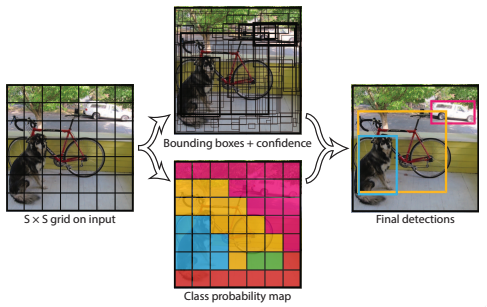

In [7]:
display(Image('./Fig/04_Yolo_model.png', width=500))

It demonstrates Yolo models detection as a regression problem. The image was devided into an $S \times S$ grid and for each grid cell, $B$ bounding boxes, confidence for those boxes, and $C$ class probabilities are predicted. These predictions are encoded as an $S \times S \times(B * 5+C)$ tensor. 

> In this $S \times S \times(B * 5 + C)$, what are the 5 predictions? 

### 4.2 Architecture and design of YOLOv1

#### 4.2.1 Network design

YOLOv1 network has 24 convolutionl layers followed by 2 fully connected layers. The alternaing $1 \times 1$ convolutional layers reduce the features space from preceding layers.

The model was evaluated on the PASCAL VOC detection dataset with $S=7, B=2$, and $C=20$, therefore the final prediction is a $7\times7\times30$ tensor.

<img src="https://miro.medium.com/v2/resize:fit:2000/format:webp/1*wecnsAKel05Z-Zt2DyzSSg.png" width="700"/>

As shown in the figure above, the model takes an input image of size $448\times448\times3$, and by the end of the feature extraction stage, the network produces a tensor of size $7\times7\times1024$. The $7\times7$ spatial locations encodes rich feature information about a specific region of the image. 

On top of the feature extractor sits the detection head that maps the $7\times7\times1024$ tensor to a final output of size $7\times7\times30$. For the 30 output channels, the first 10 values correspond to the two predicted bounding boxesm and the remaining 20 values represent the class logits for the object categories.

<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*HTGCK7Ryjnh8EVFJO_1Umg.png" width="400"/>

#### 4.2.2 Training: the loss function

$\begin{aligned} \lambda_{\text {coord }} \sum_{i=0}^{S^2} \sum_{j=0}^B \mathbb{1}_{i j}^{\text {obj }} & {\left[\left(x_i-\hat{x}_i\right)^2+\left(y_i-\hat{y}_i\right)^2\right] } \\ +\lambda_{\text {coord }} \sum_{i=0}^{S^2} \sum_{j=0}^B \mathbb{1}_{i j}^{\text {obj }} & {\left[\left(\sqrt{w_i}-\sqrt{\hat{w}_i}\right)^2+\left(\sqrt{h_i}-\sqrt{\hat{h}_i}\right)^2\right] } \\ & +\sum_{i=0}^{S^2} \sum_{j=0}^B \mathbb{1}_{i j}^{\text {obj }}\left(C_i-\hat{C}_i\right)^2 \\ & +\lambda_{\text {noobj }} \sum_{i=0}^{S^2} \sum_{j=0}^B \mathbb{1}_{i j}^{\text {noobj }}\left(C_i-\hat{C}_i\right)^2 \\ & \quad+\sum_{i=0}^{S^2} \mathbb{1}_i^{\text {obj }} \sum_{c \in \text { classes }}\left(p_i(c)-\hat{p}_i(c)\right)^2\end{aligned}$

$\mathbb{1}_i^{\text {obj }}$ denotes if object appears in cell $i$ and $\mathbb{1}_{i j}^{\text {obj }}$ denotes that the $j$ th bounding box predictor in cell $i$ is "responsible" for that prediction.

- The first term focuses on localizing the center of the bounding boxes, and is only activated for the bounding box that is responsible for predicting a specific object, as denoted by $\mathbb{1}_i^{\text {obj }}$.
- The second term handles the width and height of the bounding boxes, with squared roots compared, in order to reflect that small deviations in large boxes matter less than in small
boxes
- The third term measures how well the model predicts the confidence score for boxes that contain objects. 
- The fourth term deals with much larger number of bounding boxes that do not contain any object. Actually in every image many grid cells fall into this category, which pushes the "confidence" scores of those cells towards zero, often overpowering the gradient from cells
that do contain objects. This can cause training to diverge early on. To remedy this problem, the two parameters $\lambda_{\text {coord }}$ and $\lambda_{\text {noobj }}$ are applied. By setting $\lambda_{\text {coord }}=5$ and $\lambda_{\text {noobj }}=0.5$, the loss from bounding box coordinate predictions is increased while the loss from confidence predictions for boxes that do no contain objects is decreased. 
- The fifth term is responsible for classification. This classfication loss is only applied to cells that contain objects, ensuring that the background cells do not influence class predictions.

#### 4.2.3 Inference: Non-maximal suppression 

At this stage, the model produces a large number of overlapping bounding boxes, many referring to the same object. To obtain a clean final result, NMS is applied (introduced in Sec. 2.2.5): it first removes boxes with low confidence scores, then iteratively selects the highest-confidence box and suppresses all others that overlap significantly with it. Redundant detections are eliminated, leaving only the most confident, non-overlapping predictions. 

<img src="https://miro.medium.com/v2/resize:fit:2000/format:webp/1*iPIlR0fWGq5KYkTBtsSaoA.png" width="600"/>

#### 4.2.4 YOLOv1: limitations and developments beyond

There is no proposal stage, no RoI pooling, no second-stage classifier. The entire computation is a single CNN forward pass, which is directly optimizable end-to-end and way more faster.

YOLOv1 was significantly faster than Faster R-CNN but less accurate, particularly on small objects and densely packed scenes. Subsequent versions
(v2–v8) closed this gap by adopting anchor boxes (v2), multiscale detection (v3), better backbones, and eventually anchor-free designs (v8).

```
Input image
    │
    └─ CNN (single forward pass)
              │
              └─► S×S grid → B boxes + confidence + C class probs per cell
                                          │
                                        NMS
                                          │
                                    Final detections
```

Feel free to check [this review](https://www.mdpi.com/2504-4990/5/4/83) for a comprehensive understanding of evolution of Yolo architectures.

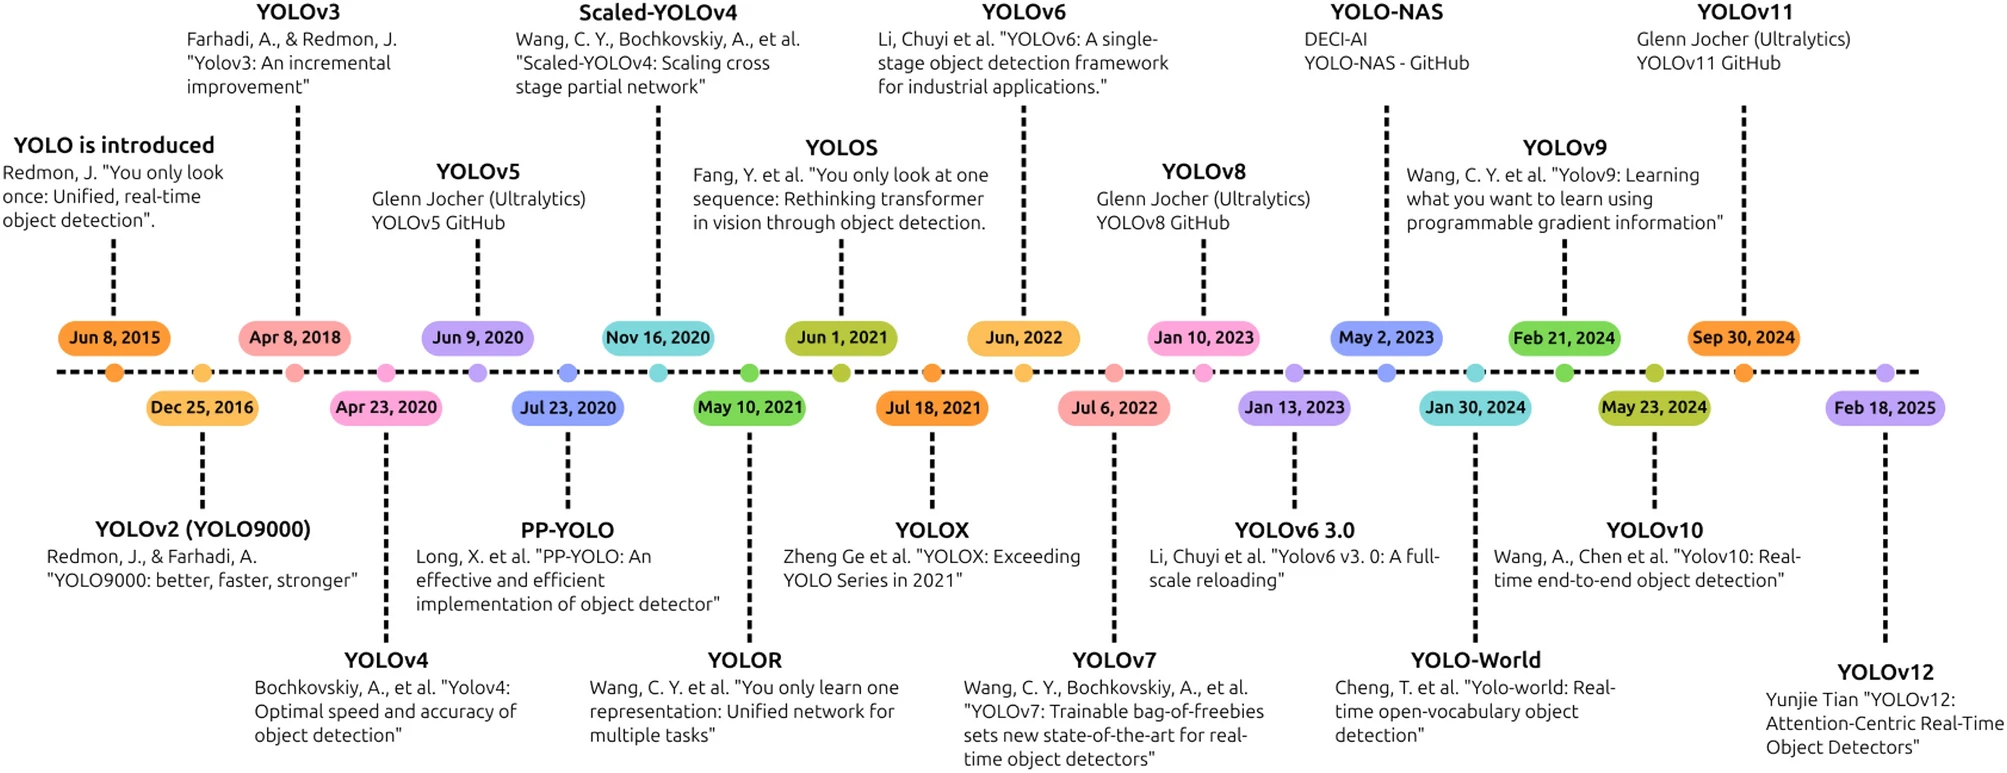

In [8]:
display(Image('./Fig/04_Yolo_evo.png', width=1100))

[Ref for this figure](https://www.nature.com/articles/s41598-025-26645-2)

While the figure above stops at YOLOv12, a few more steps sit between there and the models we use today. **YOLOv10** (2024) was the first to pioneer NMS-free detection. **YOLO11** (Oct. 2024, official Ultralytics release) is what we will use in the hands-on session. It builds on v8's anchor-free design with a more efficient backbone and an added attention module, achieving higher accuracy with fewer parameters than v8. The community-driven **YOLOv12/v13** explored attention-centric architectures in parallel but are outside the mainstream Ultralytics line.

**YOLO26** (2025) is the current frontier. It builds further on YOLO11, adding NMS-free end-to-end inference and removing Distribution Focal Loss (DFL) for edge-device efficiency. We cover it briefly in section 4.4 as a pointer to where the field is heading.

```
                     v1          v8         v10        v11         v26
                     │           │           │          │           │
  proposal-free   ✓ (grid)  ✓ (grid)   ✓ (grid)  ✓ (grid)   ✓ (grid)
  anchor-free        ✗          ✓           ✓          ✓           ✓
  attention          ✗          ✗           ✗          ✓ (C2PSA)   ✓
  NMS required        ✓          ✓         ✗ (first)   ✓         ✗ (refined)

The following figure illustrates how Ultralytics YOLO has steadily expanded its capabilities beyond detection to become a versatile multi-task vision framework.

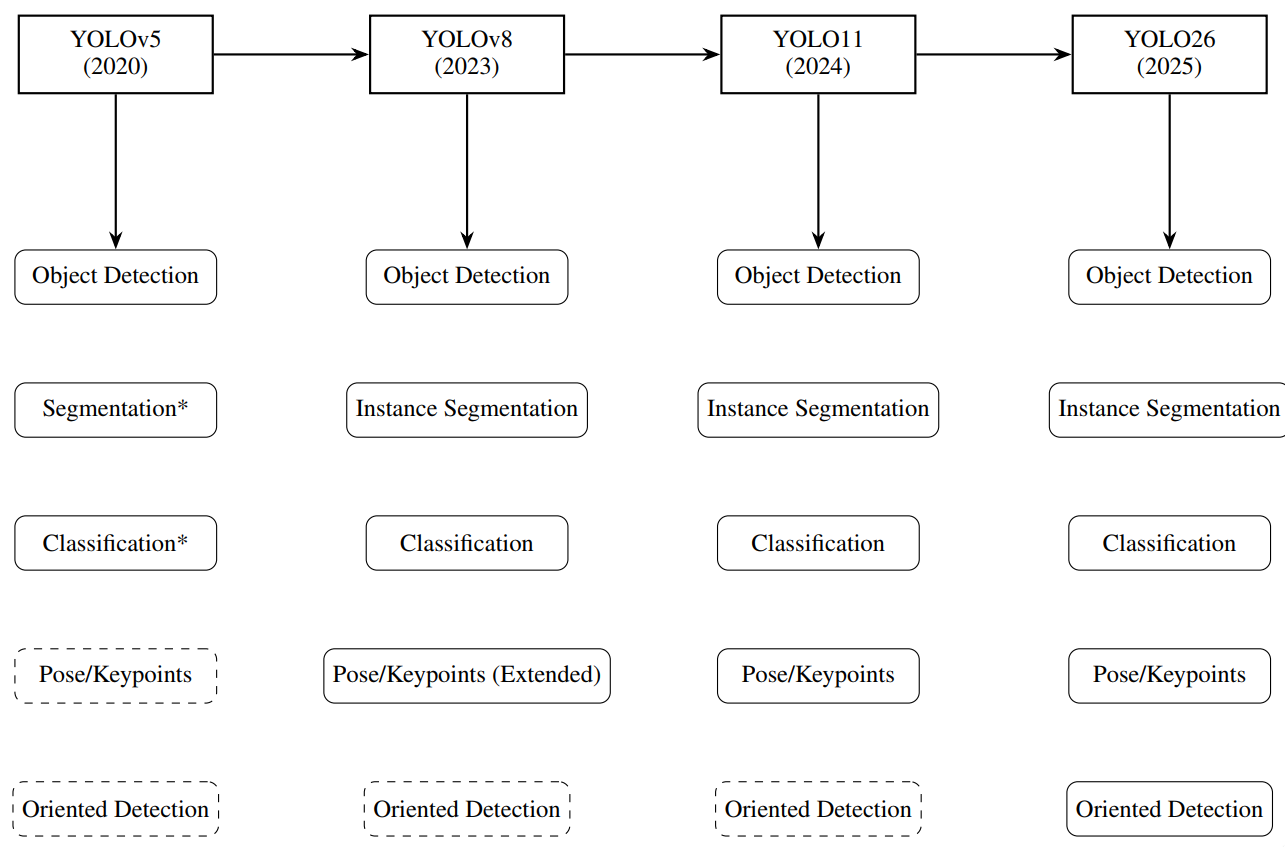

In [9]:
display(Image('./Fig/04_Yolo_ultralytics.png', width=600))

[Ref for this figure](https://arxiv.org/abs/2510.09653v2)
Timeline of Ultralytics YOLO models. Solid boxes = supported natively, dashed models = not supported. * indicates feature added later via community extensions.

> The rest of this section covers YOLO11's architecture in detail (4.3 for detection, 4.4 for segmentation), then briefly introduces what YOLO26 adds on top (4.5).

### 4.3 YOLO11 architecture for detection

YOLO11 follows the standard three-stage YOLO structure: **backbone → neck → head**. Each stage has a specific role and YOLO11 introduces targeted improvements at each one.

```
Input image
    │
    └─ Backbone (feature extraction)
              │
              └─ Neck (multi-scale feature fusion)
                        │
                        └─ Head (prediction: boxes + classes)
```

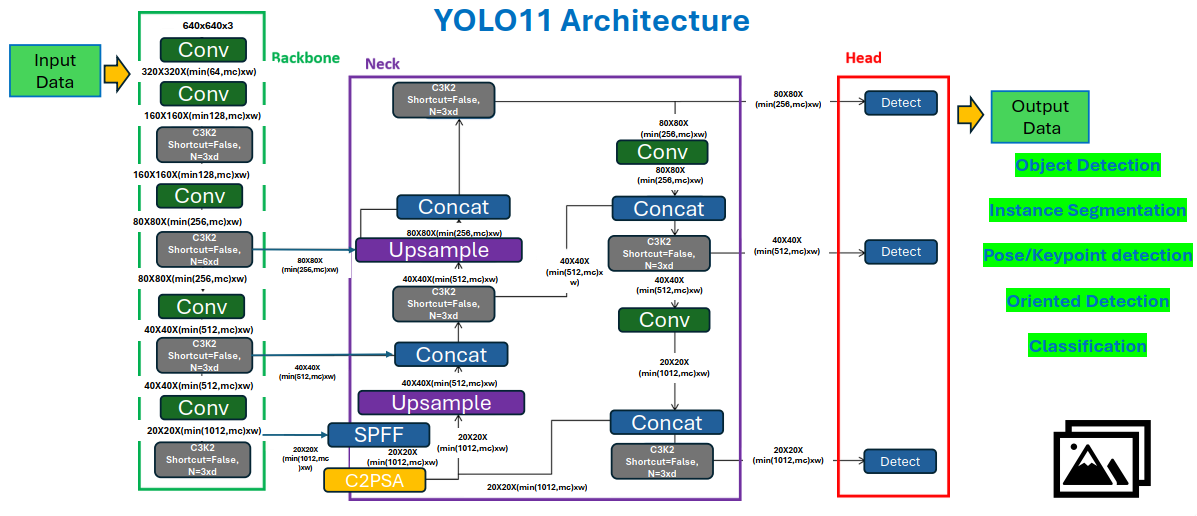

In [10]:
display(Image('./Fig/04_Yolo11_archi.png', width=900))

#### 4.3.1 Backbone: C3k2 blocks + SPPF + C2PSA

The backbone extracts hierarchical features from the input image at progressively coarser spatial resolutions. YOLO11 introduces three key building blocks here:

**C3k2 (Cross Stage Partial with bottleneck kernel size 2)**
Replaces the C2f blocks used in YOLOv8. The CSP design splits the feature map into two paths — one goes through convolutional bottleneck blocks, one bypasses them — then merges both, improving gradient flow and feature reuse. The "k2" refers to the bottleneck convolutions inside the heavy path using smaller **2×2 kernels** (rather than the standard 3×3), while the outer convolutions remain 3×3. This reduces parameters and computation within the bottleneck while preserving the effective receptive field of the overall block, giving C3k2 its efficiency advantage over YOLOv8's C2f blocks.

**SPPF (Spatial Pyramid Pooling — Fast)**
Applies max pooling at multiple scales in sequence (rather than in parallel, as in earlier SPP designs) to capture context from different receptive field sizes efficiently. This gives the network a sense of global context without losing local detail, *which can be particularly useful for detecting defects at varying scales.*

**C2PSA (Convolutional block with Parallel Spatial Attention)**
Adds a lightweight spatial attention mechanism after SPPF, allowing the network to focus on the most relevant regions of the feature map while suppressing background noise and highlighting candidate object regions. This is what makes YOLO11 notably better than v8 at small-object detection.

#### 4.3.2 Neck: PAN/FPN with C3k2

The neck fuses feature maps from different backbone stages, combining coarse semantic information (deep layers) with fine spatial detail (shallow layers). YOLO11 uses a **PAN/FPN-style (Path Aggregation Network / Feature Pyramid Network)** neck: features flow top-down (semantic context from deep layers to shallow) and bottom-up (spatial detail from shallow layers to deep), so every scale in the pyramid benefits from both, thus enabling accurate detection of defects at all sizes.

C3k2 blocks are reused in the neck as well, keeping computational cost low while maintaining discriminative power at each scale.

*(This neck is shared infrastructure for both detection and segmentation. The segmentation head in 4.3 reads from the same fused multi-scale features.)*

### 4.3.3 Detection head: anchor-free, multi-scale

The neck produces feature maps at three different scales, each suited to detecting objects of a different size range:

- Large $80 \times 80$ Small objects (fine spatial detail)
- Medium $40 \times 40$ Medium objects
- Small $20 \times 20$ Large objects (rich semantic context)

This multi-scale design directly addresses a core challenge in industrial inspection: defects can vary enormously in size: a thin scratch occupies only a few pixels, while a large rolled-in scale defect can span a significant portion of the image. A single-scale detector would need to compromise between spatial resolution and semantic richness, performing poorly at one end of the size spectrum. By maintaining three separate detection layers, each operating at its own resolution, YOLO11 can detect small defects with fine spatial precision *and* large defects with strong semantic context simultaneously.

Each detection layer predicts, for every spatial location:

- **Box coordinates** (center x, y, width, height): directly regressed, anchor-free
- **Class probabilities**: one score per class
- **Confidence score**: how likely an object is present at this location

Since the model is anchor-free, there are no predefined anchor shapes to match against, i.e., box dimensions are predicted directly, making the model easier to adapt to new datasets (no anchor shape tuning required per domain).

Candidate predictions from all three scales are then filtered by **NMS** at inference time to remove duplicate detections of the same object.

### 4.4 YOLO11 architecture for segmentation

#### 4.4.1 Same backbone and neck, added segmentation head

YOLO11's segmentation variant (**YOLO11-seg**) shares the **exact same backbone and neck** as the detection model described in 4.3. No additional feature extraction is needed. Segmentation is detection plus one additional output branch, trained jointly.

The detection head already identifies **where** each object is (bounding box + class). The segmentation head adds **what shape it is** using the same shared features, which is a pixel-level mask.

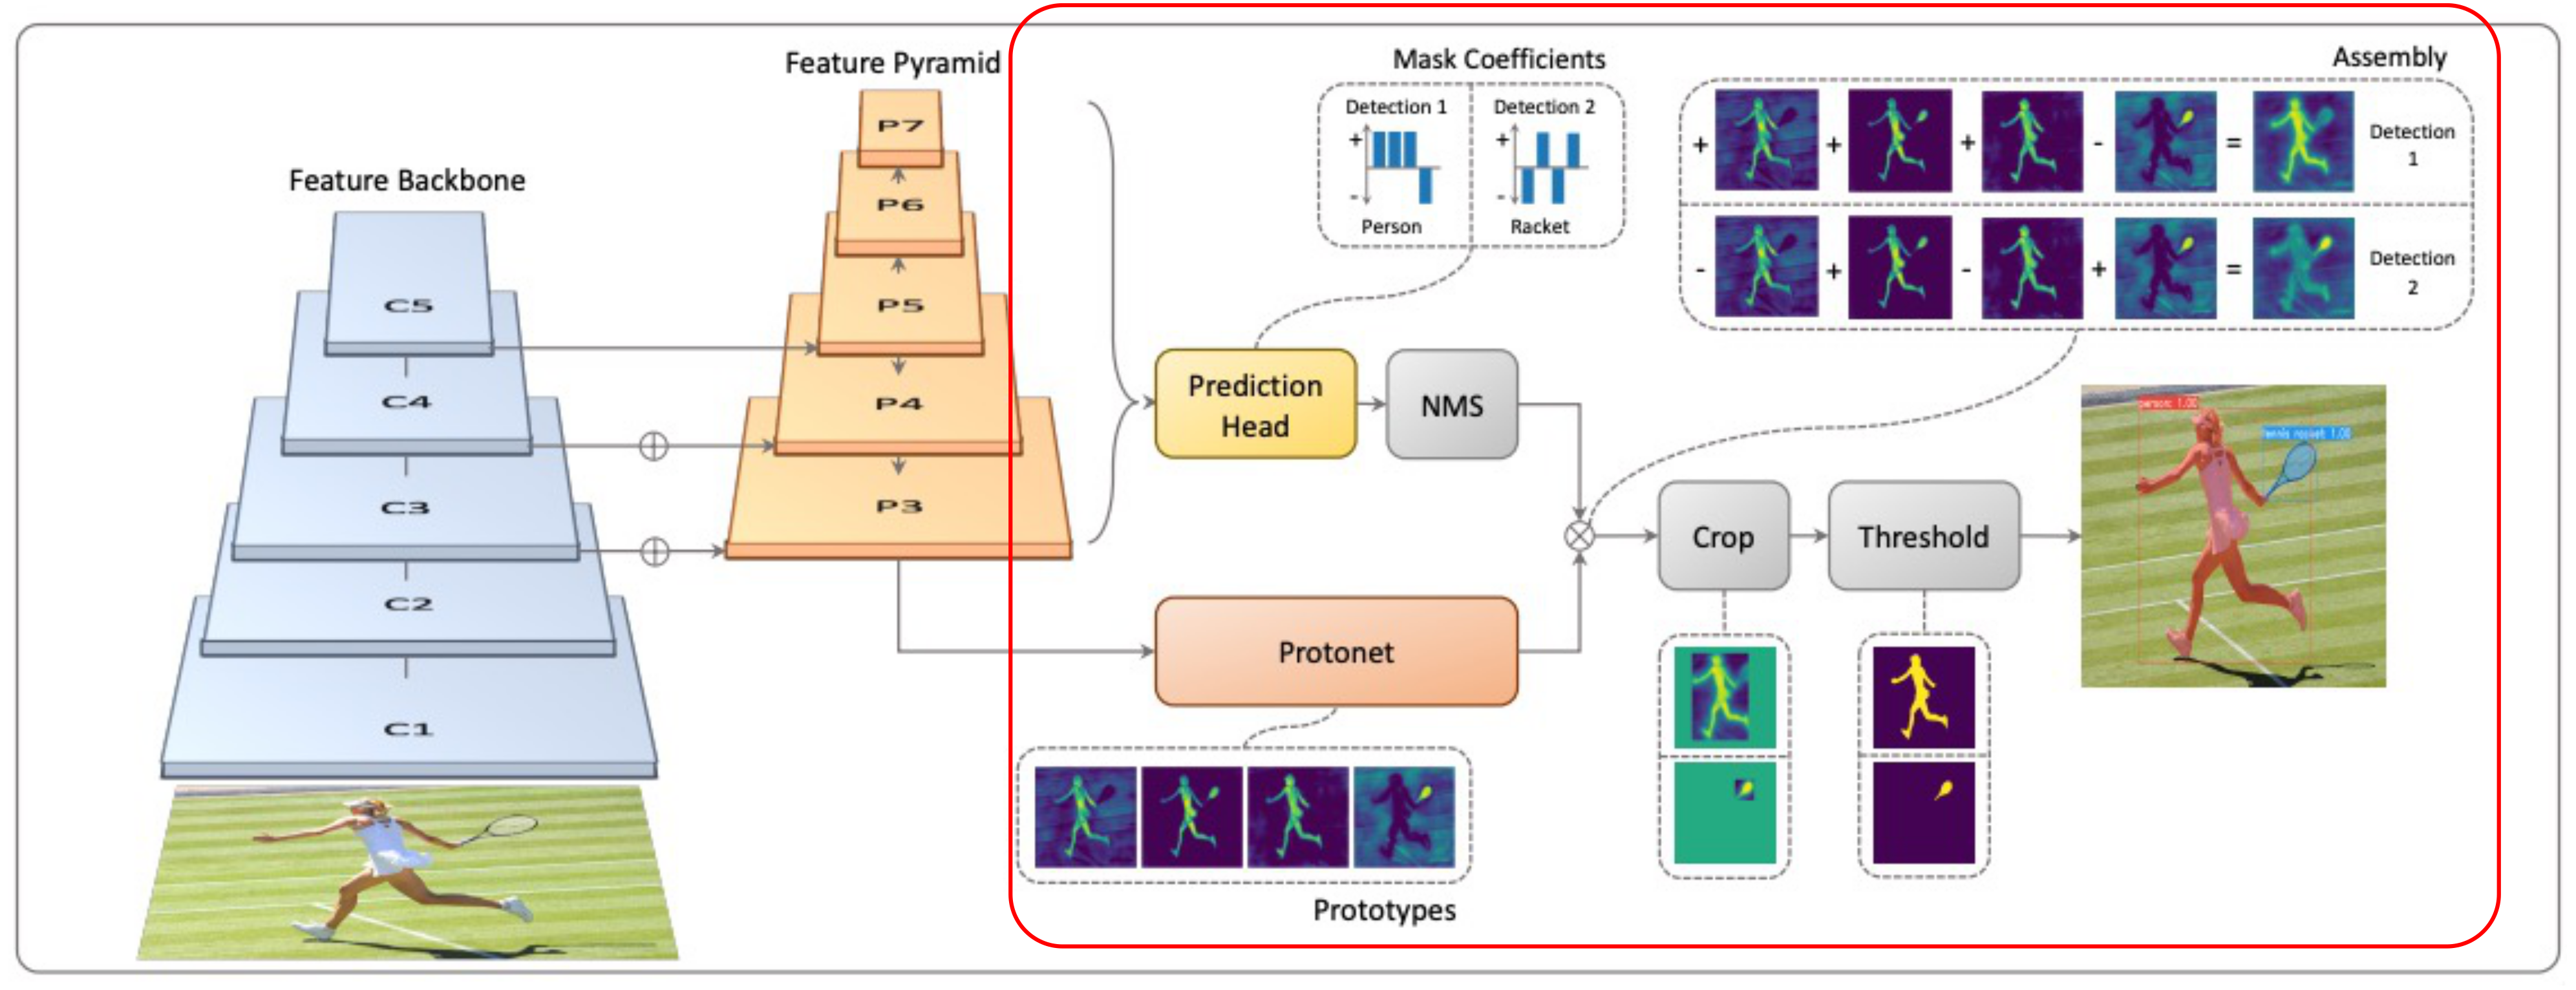

In [11]:
# Here we use YOLACT Architecture to demonstrate more details for segmentation 
# (marked by red frame)[arXiv:1904.02689v2]
display(Image('./Fig/04_Yolo_seg.png', width=650))

#### 4.4.2 Prototype masks and mask coefficients

Rather than predicting a full-resolution mask per object directly (expensive and slow), YOLO11-seg uses a two-part approach inherited from YOLACT (You Only Look At Coefficients, Bolya et al., ICCV 2019, see the figure above):

1. **Prototype masks**

   A small auxiliary branch runs in parallel with the detection head, taking the neck's feature maps as input and producing a fixed set of **$k$ prototype masks** (typically $k=32$), each a low-resolution spatial map of the same height and width as the feature map, but with no object-specific meaning on its own.

   Think of the prototypes as a learned **basis** for all possible object shapes in the dataset, which is roughly analogous to how a small set of basis vectors can linearly combine to approximate many different vectors. Each prototype captures a different spatial pattern: one might activate strongly at object edges, another at object centres, another at elongated horizontal regions. These $k$ prototypes are shared across every object detected in the image.

2. **Mask coefficients**

   For each detected object, the detection head predicts a vector of **$k$ mask coefficients** $\mathbf{c} \in \mathbb{R}^k$, one coefficient per prototype, alongside the usual box coordinates and class scores. These coefficients can be positive or negative, allowing flexible linear combinations.

   The final instance mask for that object is then computed as:

   $$M=\sigma\left(P C^T\right),$$

   where $P$ is an $h \times w \times k$ matrix of prototype masks and $C$ is a $n \times k$ matrix of mask coefficients for $n$ instances surviving NMS and score thresholding. $\sigma$ is the sigmoid function that squashes the output to $[0, 1]$ (producing a soft mask, thresholded to binary at inference time).

**Why this is efficient**

The key insight is that the $k$ prototype masks are computed **once** for the entire image, regardless of how many objects are detected. Each object's mask is then just a cheap linear combination applied to those shared prototypes. This avoids the computational cost of running a separate mask prediction branch for every detected object independently, which is what makes this approach fast enough for real-time use.

**What the network actually learns**

During training, the prototype branch learns to produce spatial patterns that, when linearly combined with the right coefficients, can reconstruct the ground-truth masks of all objects in the image. The detection head simultaneously learns to predict the right coefficients for each detected object. Both are trained jointly end-to-end via a mask loss (binary cross-entropy between the predicted soft mask and the ground-truth binary mask, cropped to the object's bounding box).

### 4.5 From YOLO11 to YOLO26 (brief)

> *This section is a pointer to where the field is heading — not required for the hands-on session.*

YOLO26 (arXiv 2606.03748, Jocher et al., 2025) builds directly on YOLO11, adding three key changes:

- **NMS-free end-to-end inference** (pioneered in v10, now refined): the model produces clean, non-redundant predictions natively, removing the NMS post-processing step entirely
- **DFL removed**: Distribution Focal Loss is replaced by a simpler regression target, improving compatibility with edge hardware and reducing inference latency
- **Training-time improvements** (ProgLoss, STAL, MuSGD): each targets a specific training stability or small-object issue; implementation details, not architectural shifts

The backbone-neck-head structure, anchor-free design, shared segmentation head, and multi-task capability are all inherited directly from YOLO11 — YOLO26 refines the outputs and training, not the core architecture.

For further reading, see the official paper: [arXiv 2606.03748](https://arxiv.org/abs/2606.03748).

## 5. UNet and Transformer-Based Segmentation

YOLO11-seg (section 4) is designed for **instance segmentation**: detecting and masking individual object instances in real time. This chapter introduces a complementary family of architectures built for **semantic segmentation**, where the goal is to assign a class label to every pixel in the image rather than to individual instances.

We begin with **classic U-Net**, the foundational encoder-decoder architecture that defined modern segmentation, then examine **why transformers were brought in**, and finally look at **SegFormer** as a representative and widely adopted transformer-based segmentation model. The chapter closes with a structured comparison between these approaches and YOLO11-seg.

### 5.1 Semantic segmentation vs instance segmentation

Before introducing U-Net, it is worth being precise about what semantic segmentation does and does not do, relative to the instance segmentation covered in section 4.

| | Semantic segmentation | Instance segmentation |
|---|---|---|
| Output | Per-pixel class label | Per-object mask |
| Distinguishes instances? | ✗ | ✓ |
| Can count objects? | ✗ | ✓ |
| Typical architecture | U-Net, SegFormer | YOLO11-seg, Mask R-CNN |
| Speed | Slower | Faster (YOLO) |
| Strength | Fine boundary detail | Multiple overlapping objects |

```
Input image          Semantic segmentation       Instance segmentation
                     (U-Net)                     (YOLO11-seg)
┌──────────┐         ┌──────────┐                ┌──────────┐
│          │         │  bg  bg  │                │  bg  bg  │
│ ░░   ▓▓  │  ──►    │  def def │                │  #1  #2  │
│ ░░   ▓▓  │         │  def def │                │  #1  #2  │
└──────────┘         └──────────┘                └──────────┘
two defects          merged into one class       distinguished as
                    'defect'                     separate instances
```

The choice depends on the inspection task: if one only needs to locate and classify defect regions, semantic segmentation suffices. If one needs to count or measure individual defect instances separately, instance segmentation is required.

### 5.2 Classic U-Net

U-Net was introduced by Ronneberger et al. (2015) for biomedical image segmentation and quickly became the dominant architecture for dense pixel-level prediction tasks in industrial and medical imaging alike.

**Reference**: Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. *MICCAI*. arXiv: [1505.04597](https://arxiv.org/abs/1505.04597)

#### 5.2.1 Encoder-decoder with skip connections

UNet follows a symmetric **encoder-decoder** structure, with the key innovation of **skip connections** between corresponding encoder and decoder stages:

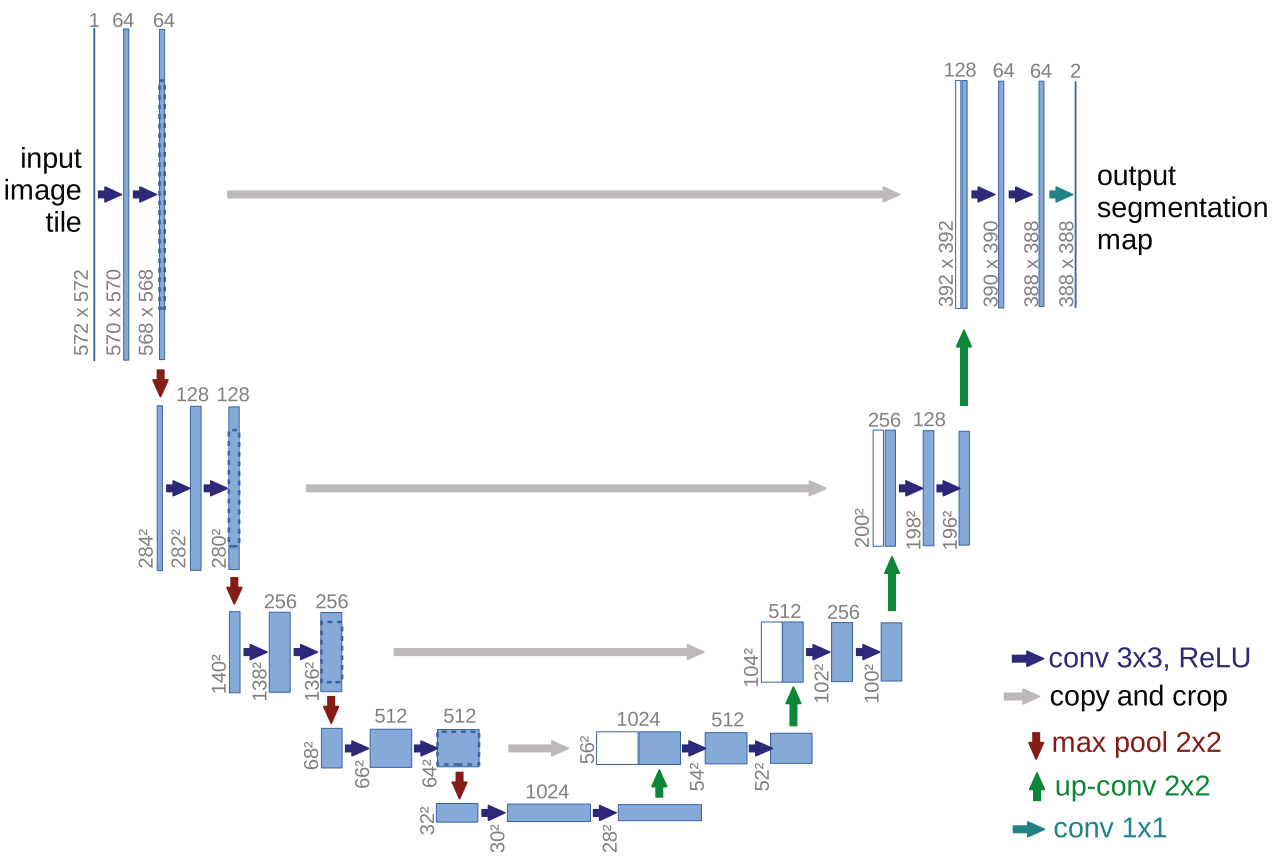

In [12]:
display(Image('./Fig/04_unet.png', width=1000))

The core idea of U-Net is to supplement a usual contracting network by successive layers, where pooling operators are replaced by upsampling operators. 

**How U-Net differs from traditional CNNs**

**1. No fully connected layers — the output is a spatial map, not a single label**

Earlier CNN architectures (VGG, AlexNet) ended with fully connected layers that flatten all spatial information into a single vector, producing one label for the whole image. U-Net replaces these with a 1×1 convolution at the final layer, which classifies each spatial position independently and preserves the 2D structure of the image all the way to the output. The result is a full segmentation map (one class label per pixel) rather than a single image-level prediction.

**2. Valid convolution — predictions are only made where information is complete**

A 3×3 convolution requires a 3×3 neighbourhood around each pixel to compute its output. For pixels at the image border, part of that neighbourhood lies outside the image. U-Net avoids this problem by using *valid* convolution, i.e., computing outputs only where the full 3×3 neighbourhood is available, and discarding border positions where it is not.

The consequence is that the output segmentation map is slightly smaller than the input image. Each valid convolution trims 1 pixel from each border, and this shrinkage accumulates across all layers:

​```
Input:  572×572 --> repeated valid convolutions (no padding) --> Output: 388×388 (predictions only for pixels with complete context) 
​```

Only the 388×388 central region of the input has a corresponding prediction. The outer border pixels, whose neighbourhood would extend outside the image, are simply excluded. No zero-padding is used anywhere, so no artificial values are ever introduced into the computation.

> *Note: most practical U-Net implementations today use **same padding** instead, producing an output the same size
> as the input. Valid convolution was a deliberate design choice of the original 2015 paper for maximum boundary 
> precision, but it is not a fundamental requirement of the UNet architecture.*

#### 5.2.2 Why skip connections matter

Without skip connections, spatial detail is progressively lost as the encoder downsamples. The decoder receives only a coarse, semantically rich representation and must reconstruct fine boundaries from limited information. Skip connections short-circuit this loss by providing the decoder with access to high-resolution features at every scale:

```
Without skip connections:          With skip connections (UNet):

Encoder ──► Bottleneck             Encoder ──► Bottleneck
                 │                    │              │
              Decoder              (skip)         Decoder
                 │                    └──────────────┤
            coarse mask                        fine mask
        (blurry boundaries)              (sharp boundaries)
```

This is particularly important for industrial defect segmentation, where the precise boundary delineation that distinguishes exactly which pixels belong to a scratch versus background steel, is critical for downstream measurement and classification.

<div style="background-color:#f0f4ff; border-left:5px solid #4a6fa5; padding:16px 20px; border-radius:6px; margin:16px 0; max-width:90%;">
<strong>📋 Note: skip connections — same idea, different motivation</strong>
<p>These skip connections serve a different purpose from ResNet's residual connections (covered in <a href="../3-TL-VGG-ResNet-ViT-lesson/">Episode 3, Sec. 5.2</a>). ResNet's shortcuts address the <em>vanishing gradient problem</em> in very deep networks. They give the training signal a direct path backward so early layers keep learning. U-Net's shortcuts address <em>spatial detail loss caused by pooling</em>. They carry high-resolution encoder features directly to the decoder so fine boundaries can be reconstructed. Same structural idea, different motivation.</p>
</div>

### 5.3 Why transformers for segmentation?

Classic U-Net is built entirely on convolutional layers, which have a fundamental limitation: **local receptive fields**. Each convolution only looks at a small neighbourhood of pixels at a time. To capture long-range dependencies (e.g. a defect pattern that spans the image), you need many stacked layers, which is slow and may still miss global structure.

**The limitation of pure CNNs for segmentation**

```
CNN convolution:                    Self-attention (Transformer):

┌─────────────────────┐             ┌─────────────────────┐
│  . . . . . . . . .  │             │  . . . . . . . . .  │
│  . ┌───┐ . . . . .  │             │  . ←───────────── . │
│  . │3×3│ . . . . .  │             │  . . . . . . . ↕ .  │
│  . └───┘ . . . . .  │             │  . . . . ←───────.  │
│  . . . . . . . . .  │             │  . . . . . . . . .  │
└─────────────────────┘             └─────────────────────┘
sees local neighbourhood only       every pixel attends to
                                    every other pixel
```

**Self-attention** is the core mechanism of transformers and computes relationships between every pair of positions in the image simultaneously, giving the model inherent access to global context at every layer. This is especially valuable for segmentation tasks where:

- Defect appearance depends on surrounding context (e.g. a scratch looks different near an edge vs centre)
- Long-range spatial patterns need to be recognised (e.g. a rolling defect that spans the full image width)
- Fine boundaries need to be recovered with global consistency

The challenge is that pure transformer models (like the original ViT applied to segmentation) produce only **single-scale, low-resolution feature maps** while losing spatial detail in the process. Transformer-based segmentation architectures like SegFormer solve this by combining transformer encoders with hierarchical, multi-scale designs.

### 5.4 SegFormer

SegFormer (Xie et al., 2021) is a simple and efficient transformer-based segmentation framework that addresses the limitations of both pure CNNs (local receptive field only) and early transformer segmentation models (single-scale features, heavy decoders).

**Reference**: Xie, E. et al. (2021). SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers. *NeurIPS 2021*. arXiv: [2105.15203](https://arxiv.org/abs/2105.15203)

#### 5.4.1 Architecture overview

SegFormer has two components: a **hierarchical Mix Transformer (MiT) encoder** and a **lightweight all-MLP decoder**.

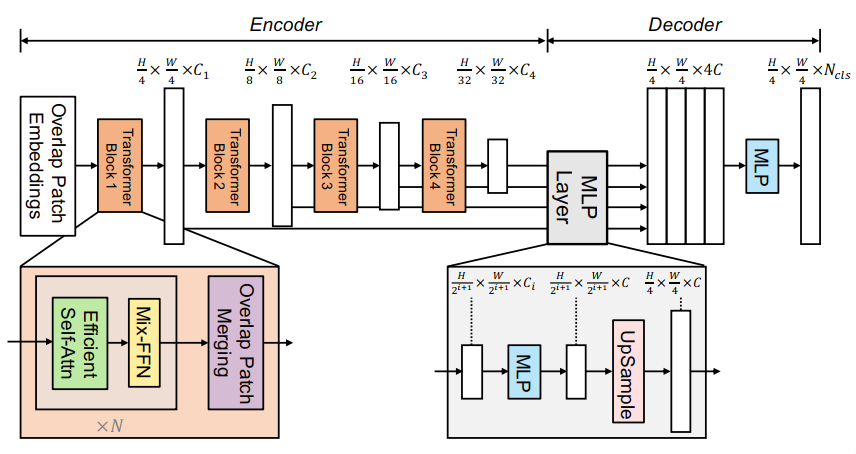

In [13]:
display(Image('./Fig/04_SegFormer.png', width=800))

#### 5.4.2 Mix Transformer encoder (MiT)

The MiT encoder is inspired by ViT but redesigned for dense prediction tasks. Key differences from standard ViT:

**Hierarchical, multi-scale features**: unlike ViT which produces a single low-resolution feature map, MiT produces feature maps at four different scales (H/4, H/8, H/16, H/32), analogous to the multi-scale features in U-Net's encoder or YOLO11's backbone. This is essential for segmentation across object scales.

**Overlapping patch merging**: patches overlap slightly when being merged at each stage, preserving local continuity and boundary detail that non-overlapping patch splitting would lose.

**No positional encoding**: standard transformers require positional encodings to tell the model where in the image each patch is. MiT replaces these with a **Mix-FFN** (a small depthwise convolution inside the feed-forward layers) that implicitly encodes positional information. This means SegFormer generalises to image resolutions different from training without accuracy loss, which is an important practical advantage.

**Efficient self-attention**: standard self-attention scales quadratically with sequence length (i.e. number of patches), which is expensive for high-resolution images. MiT uses **Sequence Reduction** to reduce the key and value sequences before computing attention, dramatically cutting computational cost at high-resolution stages.

#### 5.4.3 Lightweight all-MLP decoder

The decoder is deliberately simple, which is also a key design choice that SegFormer's authors argue is made possible precisely *because* the hierarchical transformer encoder already captures both local and global context. A complex decoder is not needed:

1. Each of the four encoder feature maps is passed through a **linear projection** to a common channel dimension $C$
2. All four maps are **upsampled** to the same spatial resolution (H/4 × W/4)
3. The four maps are **concatenated** and fused with a linear layer
4. A final linear layer projects to the number of classes, and the output is upsampled to full image resolution

The entire decoder adds negligible computational overhead. Most of the model's capacity is in the encoder, where it belongs.

This contrasts with U-Net's decoder, which uses transposed convolutions and skip connections to recover spatial detail — necessary because UNet's CNN encoder loses fine detail through pooling, so the decoder has to reconstruct it. SegFormer's encoder retains multi-scale detail throughout (via the hierarchical stages), so the decoder can afford to be minimal.

**Visualization and interpretation regarding the effectiveness of MLP decoder on transformers**

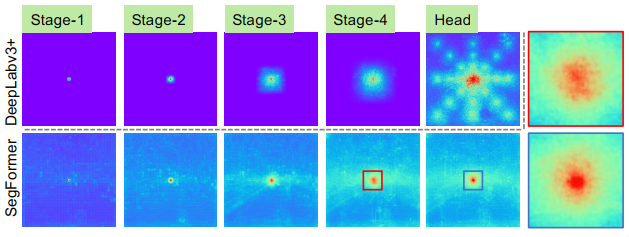

In [14]:
# Effective Receptive Field (ERF) on cityscapes.
display(Image('./Fig/04_SegFormer_ERF.png', width=600))

- SegFormer’s encoder naturally produces local attentions which resemble convolutions at lower
stages, while able to output highly non-local attentions that effectively capture contexts at Stage-4.
- The ERF of the MLP head (blue box) is different from that of Stage-4 (red box), demonstrating a significant stronger local attention besides the non-local attention.
- DeepLabv3+'s CNN-based encoder remains limited to a relatively small, spatially fixed receptive field even at its deepest stage.

### 5.5 Comparison: U-Net vs SegFormer vs YOLO11-seg

| | U-Net | SegFormer | YOLO11-seg |
|---|---|---|---|
| **Task** | Semantic | Semantic | Instance |
| **Encoder** | CNN (ResNet variants) | Transformer (MiT) | CNN (C3k2 + C2PSA) |
| **Decoder** | CNN + skip connections | Lightweight MLP | Prototype masks + coefficients |
| **Multi-scale features** | Via skip connections | Via hierarchical stages | Via PAN/FPN neck |
| **Global context** | Limited (local conv) | Strong (self-attention) | Partial (C2PSA attention) |
| **Positional encoding** | N/A | No (Mix-FFN) | N/A |
| **Real-time capable** | ✗ | ✗ (approx.) | ✓ |
| **Distinguishes instances** | ✗ | ✗ | ✓ |
| **Typical use case** | Medical/industrial masks | Scene parsing, high-res images | Real-time multi-object detection + segmentation |

**Design philosophy comparison**

- **U-Net**: recover spatial detail in the decoder via skip connections. What the encoder loses through pooling, the decoder rebuilds by referencing earlier encoder features
- **SegFormer**: preserve multi-scale detail in the encoder via hierarchical transformer stages. The decoder stays lightweight because the encoder never throws away spatial detail in the first place
- **YOLO11-seg**: share backbone features between detection and segmentation. Segmentation is an additional output branch, not a separate pipeline, prioritising speed and real-time capability